# Notebook 5 — Results Analysis

Combines CNN and HOG+SVM results, generates comparison figures, and runs image-level statistics.

In [1]:
import cv2, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import entropy as scipy_entropy

PROJECT_DIR = Path.cwd().parent
RESULTS_DIR = PROJECT_DIR / "outputs" / "results_v2"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures_v2"
DATASET_PATH = PROJECT_DIR / "data" / "brain_tumor_mri_dataset"
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
LABEL_MAP = {c:i for i,c in enumerate(CLASSES)}
valid_ext = {".jpg",".jpeg",".png",".bmp"}

In [2]:
cnn_df = pd.read_csv(RESULTS_DIR / "cnn_results.csv")
svm_df = pd.read_csv(RESULTS_DIR / "hog_svm_results.csv")
combined = pd.concat([cnn_df, svm_df], ignore_index=True)
combined.to_csv(RESULTS_DIR / "combined_results.csv", index=False)

# Round for display
display_df = combined.copy()
for col in ["accuracy","precision","recall","f1_score","roc_auc"]:
    display_df[col] = display_df[col].round(4)
print(display_df.to_string(index=False))
display_df.to_csv(RESULTS_DIR / "final_results_rounded.csv", index=False)

  model preprocessing  accuracy  precision  recall  f1_score  roc_auc
    CNN           raw    0.9194     0.9191  0.9194    0.9191   0.9890
    CNN           ghe    0.9074     0.9096  0.9074    0.9079   0.9844
    CNN         clahe    0.9231     0.9243  0.9231    0.9233   0.9878
HOG+SVM           raw    0.9472     0.9478  0.9472    0.9473   0.9956
HOG+SVM           ghe    0.9417     0.9421  0.9417    0.9417   0.9941
HOG+SVM         clahe    0.9500     0.9505  0.9500    0.9501   0.9948


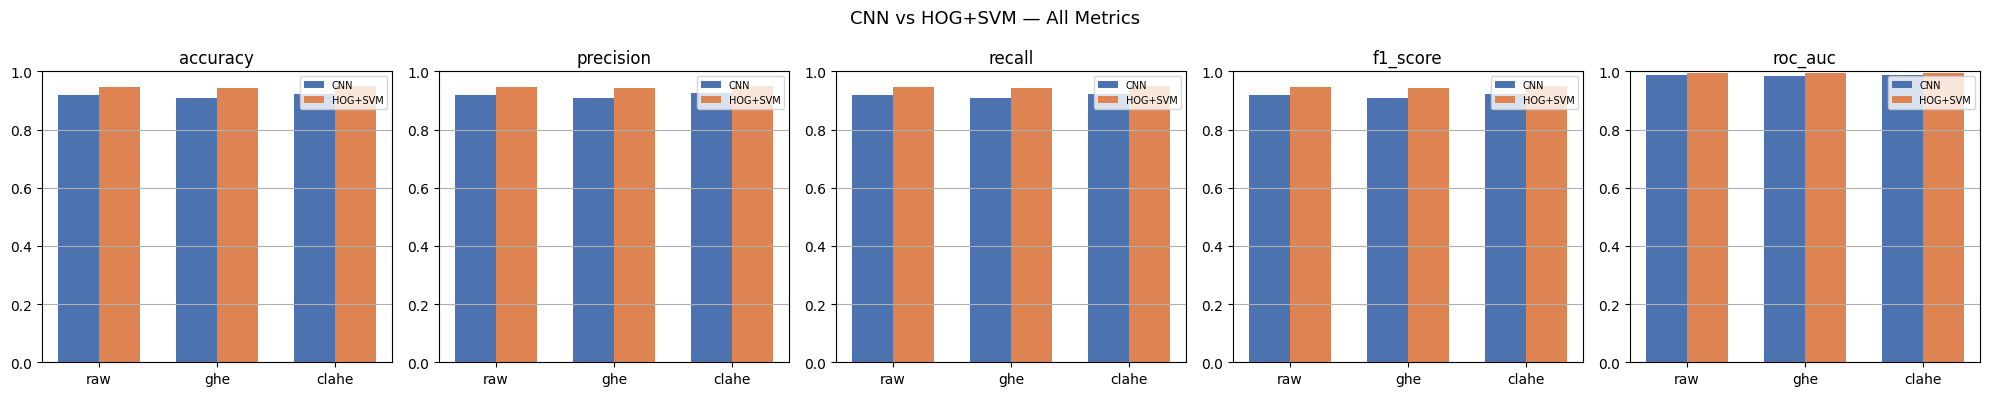

In [3]:
# Side-by-side grouped bar charts
metrics = ["accuracy","precision","recall","f1_score","roc_auc"]
methods = ["raw","ghe","clahe"]
x = np.arange(len(methods)); width = 0.35

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, metric in zip(axes, metrics):
    cnn_vals = [combined[(combined.model=="CNN") & (combined.preprocessing==m)][metric].values[0] for m in methods]
    svm_vals = [combined[(combined.model=="HOG+SVM") & (combined.preprocessing==m)][metric].values[0] for m in methods]
    ax.bar(x - width/2, cnn_vals, width, label="CNN",     color="#4C72B0")
    ax.bar(x + width/2, svm_vals, width, label="HOG+SVM", color="#DD8452")
    ax.set_title(metric); ax.set_xticks(x); ax.set_xticklabels(methods)
    ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(axis="y")
plt.suptitle("CNN vs HOG+SVM — All Metrics", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_final_comparison.png", dpi=150)
plt.show()

In [4]:
# Image-level analysis: entropy, Sobel energy, intensity stats
records = []
for split in ["Training", "Testing"]:
    for cls in CLASSES:
        folder = DATASET_PATH / split / cls
        if not folder.exists(): continue
        for p in folder.iterdir():
            if p.suffix.lower() not in valid_ext: continue
            raw = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            if raw is None: continue
            raw = cv2.resize(raw, (128,128))
            ghe   = cv2.equalizeHist(raw)
            clahe_op = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            clahe_img = clahe_op.apply(raw)
            for method, img in [("raw",raw),("ghe",ghe),("clahe",clahe_img)]:
                hist, _ = np.histogram(img.ravel(), bins=256, range=(0,256))
                hist = hist / hist.sum()
                sobel_x = cv2.Sobel(img.astype(np.float32)/255, cv2.CV_32F, 1, 0)
                sobel_y = cv2.Sobel(img.astype(np.float32)/255, cv2.CV_32F, 0, 1)
                records.append({
                    "class": cls, "preprocessing": method,
                    "entropy":      float(scipy_entropy(hist + 1e-10)),
                    "sobel_energy": float(np.mean(np.sqrt(sobel_x**2 + sobel_y**2))),
                    "mean_intensity": float(img.mean() / 255),
                    "std_intensity":  float(img.std()  / 255),
                })
img_df = pd.DataFrame(records)
img_df.to_csv(RESULTS_DIR / "image_level_analysis.csv", index=False)
print(f"Processed {len(img_df)//3} images")

Processed 7200 images


               entropy  sobel_energy  mean_intensity  std_intensity
preprocessing                                                      
clahe           4.5997        0.5048          0.2863         0.2561
ghe             3.9375        0.5349          0.4451         0.3022
raw             4.0768        0.3177          0.1867         0.1825


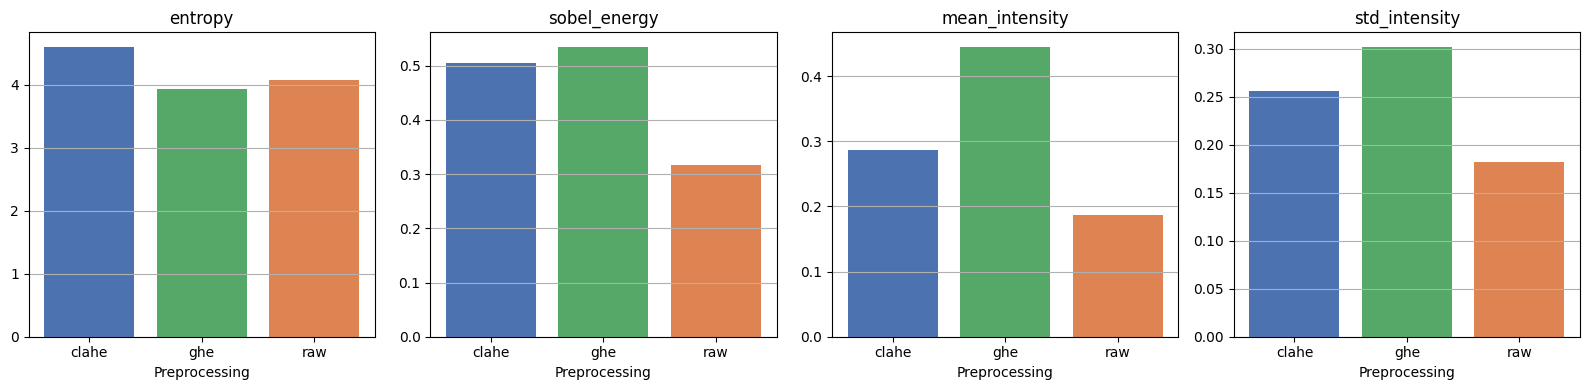

In [5]:
summary = img_df.groupby("preprocessing")[["entropy","sobel_energy","mean_intensity","std_intensity"]].mean().round(4)
print(summary)
summary.to_csv(RESULTS_DIR / "image_level_summary.csv")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["entropy","sobel_energy","mean_intensity","std_intensity"]):
    ax.bar(summary.index, summary[col], color=["#4C72B0","#55A868","#DD8452"])
    ax.set_title(col); ax.set_xlabel("Preprocessing"); ax.grid(axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_image_level_summary.png", dpi=150)
plt.show()

In [6]:
# Per-class image stats
per_class = img_df.groupby(["preprocessing","class"])[["entropy","sobel_energy"]].mean().round(4)
print(per_class)
per_class.to_csv(RESULTS_DIR / "image_level_per_class.csv")

                          entropy  sobel_energy
preprocessing class                            
clahe         glioma       4.2703        0.3972
              meningioma   4.5721        0.4555
              notumor      4.5831        0.6168
              pituitary    4.9734        0.5497
ghe           glioma       3.6221        0.4513
              meningioma   3.8910        0.4708
              notumor      3.9662        0.6017
              pituitary    4.2709        0.6157
raw           glioma       3.7416        0.2324
              meningioma   4.0377        0.2813
              notumor      4.1235        0.4382
              pituitary    4.4044        0.3188


In [7]:
# Best model summary
best = combined.loc[combined.groupby("model")["f1_score"].idxmax()].reset_index(drop=True)
print("Best preprocessing per model (by F1):")
print(best[["model","preprocessing","accuracy","f1_score","roc_auc"]].to_string(index=False))

Best preprocessing per model (by F1):
  model preprocessing  accuracy  f1_score  roc_auc
    CNN         clahe  0.923148  0.923332 0.987803
HOG+SVM         clahe  0.950000  0.950107 0.994821
